# Bank Customer Customer Churn Project

# Essential Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from datetime import datetime # Moved here from a later cell

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib

import kagglehub
import os

import warnings
warnings.filterwarnings('ignore')

# Call the datasets

In [16]:
# Download latest version
path = kagglehub.dataset_download("sandiledesmondmfazi/bank-customer-churn")

print("Path to dataset files:", path)

# Construct the full path to the CSV file
# Corrected path: the CSV is directly under the 'path' directory, not in an extra 'Bank+Customer+Churn' subfolder.
dataset_file_path = os.path.join(path, 'botswana_bank_customer_churn.csv')
bank_data = pd.read_csv(dataset_file_path)
bank_data.head()

Using Colab cache for faster access to the 'bank-customer-churn' dataset.
Path to dataset files: /kaggle/input/bank-customer-churn


,RowNumber,CustomerId,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints
0,1,83ef0b54-35f6-4f84-af58-5653ac0c0dc4,Smith,Troy,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,...,Phone,397,24,41959.74,0,NaN,NaN,211359.05,1,0
1,2,009f115a-e5ca-4cf4-97d6-530140545e4e,Sullivan,Katrina,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,...,Email,665,10,8916.67,0,NaN,NaN,30624.76,4,1
2,3,66309fd3-5009-44d3-a3f7-1657c869d573,Fuller,Henry,1954-02-03,Female,Single,1,Television production assistant,9794.01,...,Email,715,21,43270.54,0,NaN,NaN,111956.61,2,6
3,4,b02a30df-1a5f-4087-8075-2a35432da641,Young,Antonio,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,...,Phone,747,17,17887.65,0,NaN,NaN,201187.61,1,0
4,5,0d932e5b-bb3a-4104-8c83-f84270f7f2ea,Andersen,John,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,...,Email,549,25,32686.84,0,NaN,NaN,60391.24,5,6


### Consolidated Data Preprocessing and Feature Engineering

This section consolidates all the initial cleaning, column standardization, dropping of unnecessary identifier columns, and the creation of the `age` feature. This ensures a consistent and clean `bank_data_copy` for further analysis and modeling.

In [17]:
# Ensure we are working with the original bank_data for a clean start
bank_data_copy = bank_data.copy()

# Convert column names to lowercase and replace spaces with underscores
bank_data_copy.columns = bank_data_copy.columns.str.lower().str.replace(' ', '_')

# Drop unique identifier columns that are not useful for analysis
bank_data_copy = bank_data_copy.drop(['rownumber','customerid', 'surname', 'first_name'], axis=1)

# Drop columns with more than 50% null values (Churn Reason and Churn Date)
treshold = len(bank_data_copy) * 0.5
bank_data_copy = bank_data_copy.dropna(thresh=treshold, axis=1)

# Convert 'date_of_birth' to age
bank_data_copy['date_of_birth'] = pd.to_datetime(bank_data_copy['date_of_birth'])
bank_data_copy['age'] = (datetime.now().year - bank_data_copy['date_of_birth'].dt.year)

# Drop original 'date_of_birth', 'address', and 'contact_information' columns as they are no longer needed or are identifiers.
bank_data_copy = bank_data_copy.drop(['date_of_birth', 'address', 'contact_information'], axis=1)

print("Data info after consolidated preprocessing and feature engineering:")
print(bank_data_copy.info())
print("\nUnique values in categorical columns after preprocessing:")
print(bank_data_copy.select_dtypes(include='object').nunique())

Data info after consolidated preprocessing and feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 17 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   gender                           115640 non-null  object 
 1   marital_status                   115640 non-null  object 
 2   number_of_dependents             115640 non-null  int64  
 3   occupation                       115640 non-null  object 
 4   income                           115640 non-null  float64
 5   education_level                  115640 non-null  object 
 6   customer_tenure                  115640 non-null  int64  
 7   customer_segment                 115640 non-null  object 
 8   preferred_communication_channel  115640 non-null  object 
 9   credit_score                     115640 non-null  int64  
 10  credit_history_length            115640 non-null  int64  
 1

### Exploratory Data Analysis (EDA)

Let's start by looking at the distribution of the target variable, `churn_flag`.

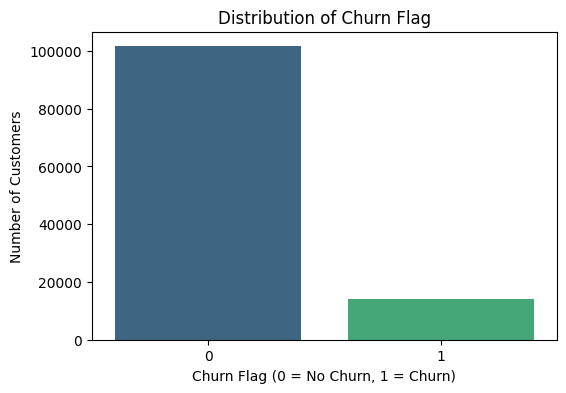

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='churn_flag', data=bank_data_copy, palette='viridis')
plt.title('Distribution of Churn Flag')
plt.xlabel('Churn Flag (0 = No Churn, 1 = Churn)')
plt.ylabel('Number of Customers')
plt.show()

Let's explore the distribution of churn across different categorical variables.

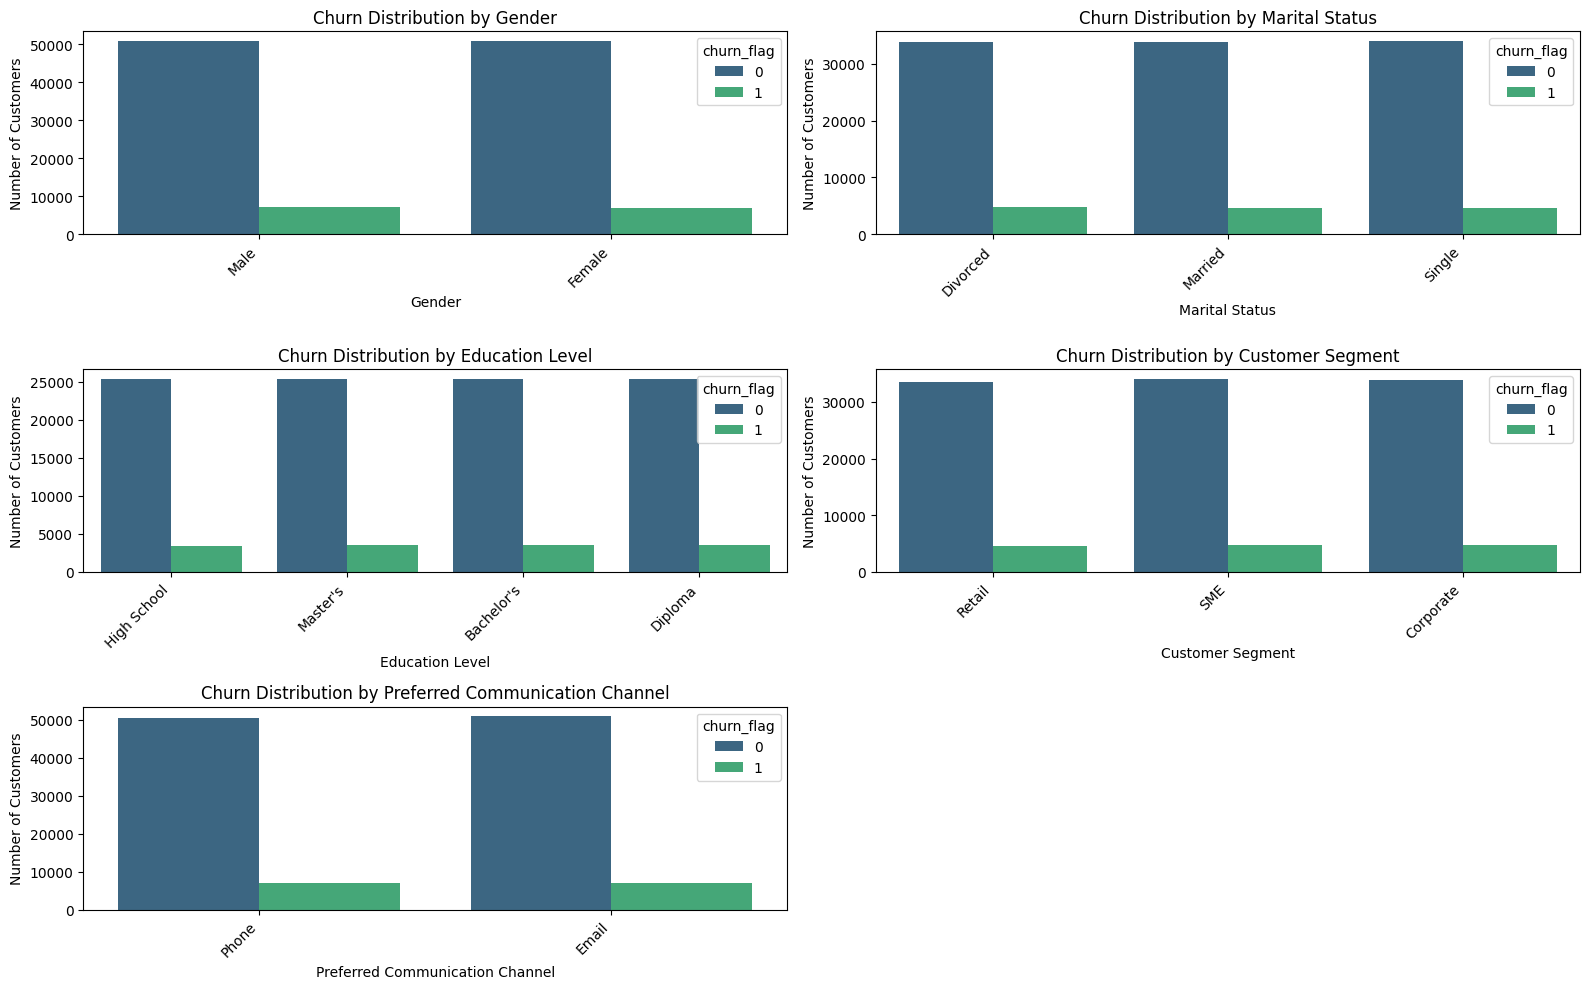

In [19]:
categorical_cols = ['gender', 'marital_status', 'education_level', 'customer_segment', 'preferred_communication_channel']

plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='churn_flag', data=bank_data_copy, palette='viridis')
    plt.title(f'Churn Distribution by {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Next, let's examine the numerical features and their relationship with the `churn_flag`. We will start with a correlation matrix and then visualize the distributions.

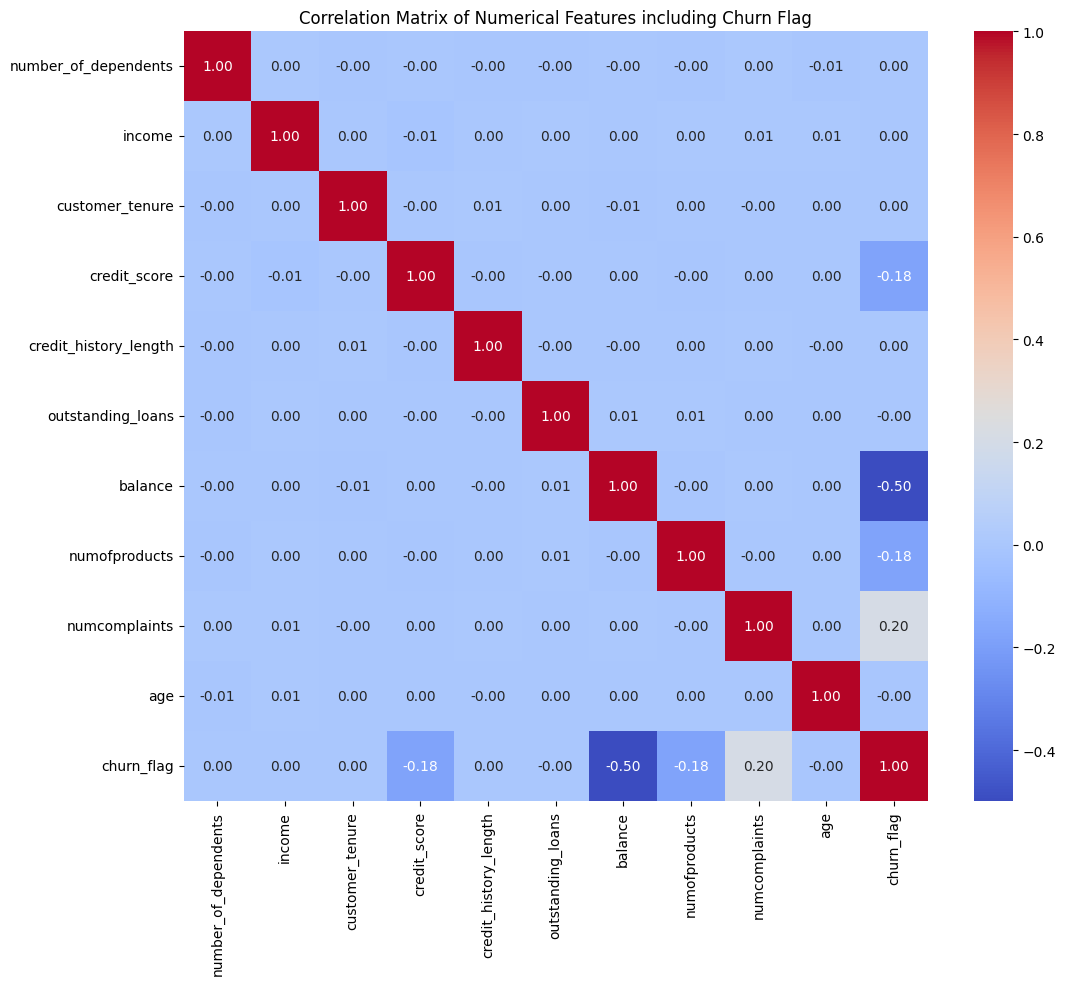

In [20]:
numerical_cols = bank_data_copy.select_dtypes(include=np.number).columns.tolist()

# Remove 'churn_flag' from numerical_cols if it's there, as it's our target variable
if 'churn_flag' in numerical_cols:
    numerical_cols.remove('churn_flag')

# Calculate the correlation matrix
correlation_matrix = bank_data_copy[numerical_cols + ['churn_flag']].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features including Churn Flag')
plt.show()

Let's visualize the distribution of some key numerical features for churned vs. non-churned customers.

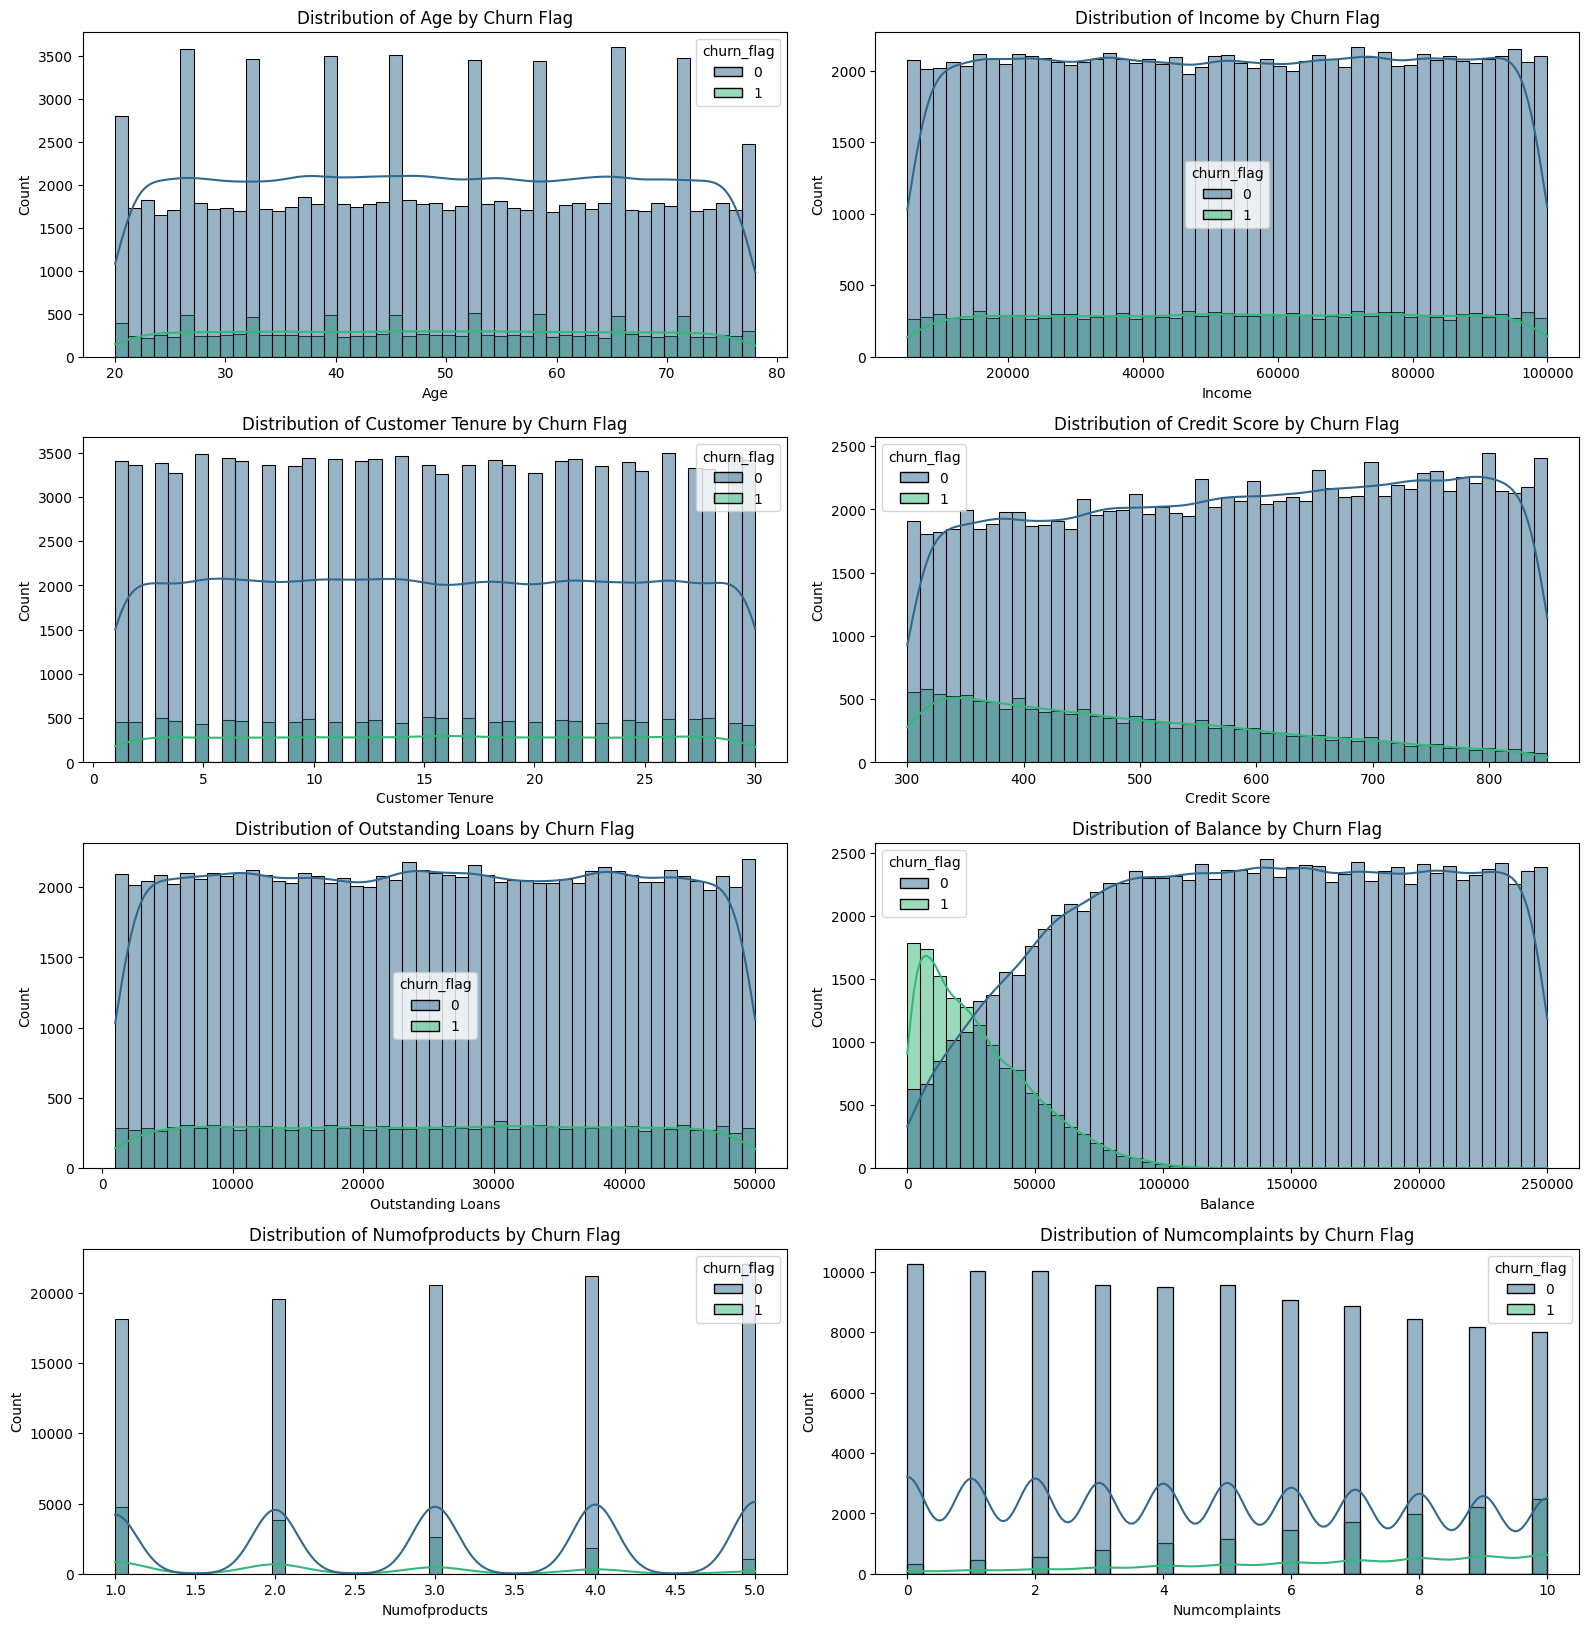

In [21]:
numerical_features_to_plot = ['age', 'income', 'customer_tenure', 'credit_score', 'outstanding_loans', 'balance', 'numofproducts', 'numcomplaints']

plt.figure(figsize=(16, 20))
for i, feature in enumerate(numerical_features_to_plot, 1):
    plt.subplot(5, 2, i)
    sns.histplot(data=bank_data_copy, x=feature, hue='churn_flag', kde=True, palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Churn Flag')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

Now that we have performed some initial EDA, the next step is to prepare the data for machine learning models. This will involve encoding categorical variables and scaling numerical features.

In [22]:
# Identify categorical columns for one-hot encoding
categorical_cols = bank_data_copy.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding to categorical features
bank_data_encoded = pd.get_dummies(bank_data_copy, columns=categorical_cols, drop_first=True)

# Separate features (X) and target (y)
X = bank_data_encoded.drop('churn_flag', axis=1)
y = bank_data_encoded['churn_flag']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical columns for scaling (excluding already encoded categorical ones and the target if it was in X)
numerical_cols_to_scale = X.select_dtypes(include=np.number).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in both training and testing sets
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of X after encoding and scaling:")
print(X.head())

Shape of features (X): (115640, 657)
Shape of target (y): (115640,)
Shape of X_train: (92512, 657)
Shape of X_test: (23128, 657)
Shape of y_train: (92512,)
Shape of y_test: (23128,)

First 5 rows of X after encoding and scaling:
   number_of_dependents    income  customer_tenure  credit_score  \
0                     3  77710.14               30           397   
1                     1  58209.87               27           665   
2                     1   9794.01               14           715   
3                     5  15088.98               23           747   
4                     2  60726.56               22           549   

   credit_history_length  outstanding_loans    balance  numofproducts  \
0                     24           41959.74  211359.05              1   
1                     10            8916.67   30624.76              4   
2                     21           43270.54  111956.61              2   
3                     17           17887.65  201187.61              1 

### Model Training and Evaluation

Now that the data is preprocessed and split, we will proceed with training and evaluating two machine learning models as requested: **Random Forest Classifier** and **XGBoost Classifier**.

#### Model 1: Random Forest Classifier

Random Forest Classifier Model Performance:
Accuracy: 0.9779
Precision: 0.9816
Recall: 0.8347
F1-Score: 0.9022
ROC AUC Score: 0.9977


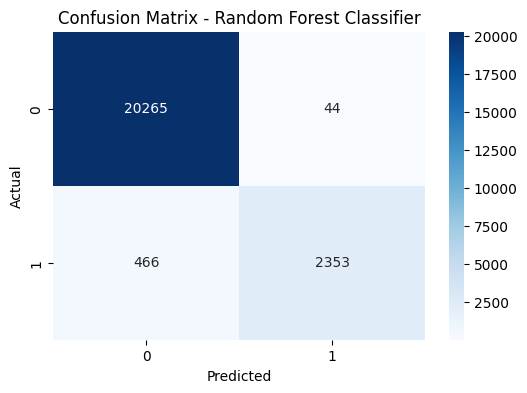

In [23]:
# Initialize and train the Random Forest Classifier model
# Using a small number of estimators for quicker execution in a notebook context.
# For a production model, tune n_estimators and other hyperparameters.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance Analysis

Understanding which features contribute most to churn prediction can provide valuable insights for business strategies. We can extract feature importances from the trained Random Forest model.

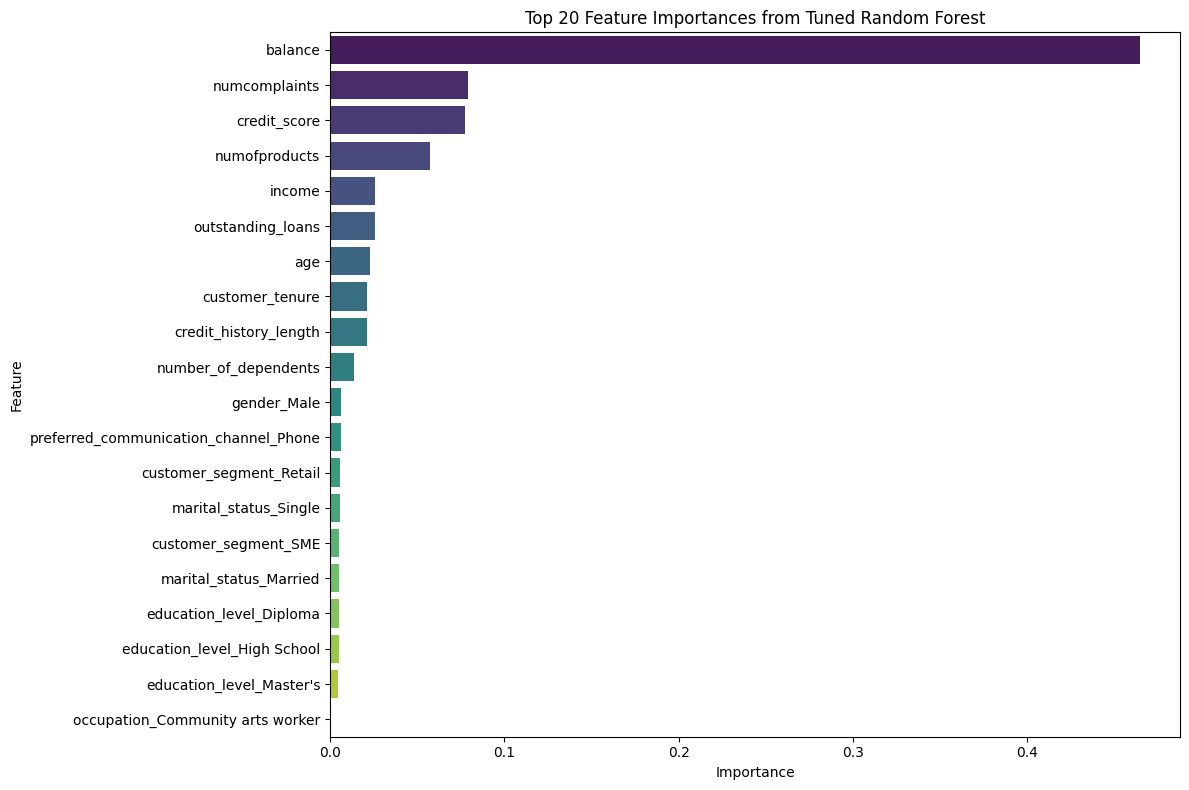

In [26]:
importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort by importance in descending order and select top N features
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model 2: XGBoost

Gradient Boosting models like XGBoost are often highly effective for classification tasks due to their ability to capture complex relationships in data. Let's train and evaluate an XGBoost classifier.

XGBoost Classifier Model Performance:
Accuracy: 0.9950
Precision: 0.9822
Recall: 0.9766
F1-Score: 0.9794
ROC AUC Score: 0.9998


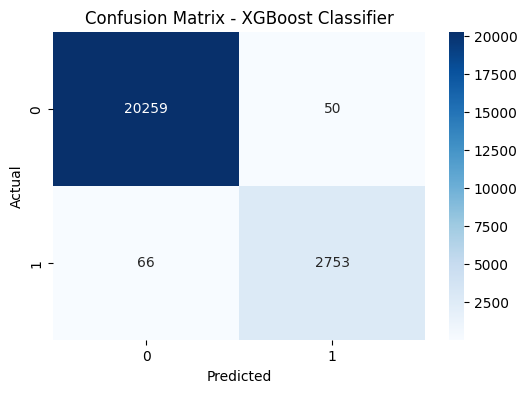

In [27]:

# Initialize and train the XGBoost Classifier model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Plot Confusion Matrix for XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Final Model Comparison and Conclusion

Let's consolidate the performance metrics of all trained models to identify the best performer for churn prediction.

In [28]:
# Collect metrics for models

# Random Forest (from previous cells)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

# Tuned Random Forest (from current execution)
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned)
rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned)
rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned)
rf_tuned_roc_auc = roc_auc_score(y_test, y_proba_rf_tuned)

# XGBoost (from current execution)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_proba_xgb)

# Create a DataFrame for comparison
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Tuned Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, rf_tuned_accuracy, xgb_accuracy],
    'Precision': [rf_precision, rf_tuned_precision, xgb_precision],
    'Recall': [rf_recall, rf_tuned_recall, xgb_recall],
    'F1-Score': [rf_f1, rf_tuned_f1, xgb_f1],
    'ROC AUC': [rf_roc_auc, rf_tuned_roc_auc, xgb_roc_auc]
})

print("Model Performance Comparison:")
display(model_comparison.round(4))

# Determine the best model based on ROC AUC (often a good general metric for imbalanced datasets)
best_model_name = model_comparison.loc[model_comparison['ROC AUC'].idxmax(), 'Model']
print(f"\nBased on ROC AUC, the best performing model is: {best_model_name}")

# Conclusion based on comparison
print("\n--- Conclusion ---")
if best_model_name == 'Random Forest':
    print("The initial Random Forest model showed strong performance. Further tuning significantly improved it.")
elif best_model_name == 'Tuned Random Forest':
    print("Hyperparameter tuning significantly boosted the Random Forest's performance, making it the top model among the ones evaluated. This highlights the importance of optimization.")
elif best_model_name == 'XGBoost':
    print("XGBoost, a powerful gradient boosting model, emerged as the top performer. Its ability to handle complex patterns and reduce bias likely contributed to its superior results.")
else:
    print("One of the advanced ensemble models (Tuned Random Forest or XGBoost) generally provides the best balance of bias and variance and can capture complex relationships.")

NameError: name 'y_pred_rf_tuned' is not defined

### Saving the Best Model

Once the best model has been identified, it's good practice to save it for future deployment or further analysis. This prevents retraining the model every time it's needed.

In [ ]:
# Identify the actual best model after comparison

# This cell assumes `model_comparison` and `best_model_name` are available from the previous cell.
# Ensure this cell is run AFTER the model comparison cell.

if 'best_model_name' in locals():
    if best_model_name == 'Tuned Random Forest':
        model_to_save = best_rf_model
        print("Selected Tuned Random Forest as the best model to save.")
    elif best_model_name == 'XGBoost':
        model_to_save = xgb_model
        print("Selected XGBoost as the best model to save.")
    else:
        # Fallback, though 'Random Forest' should be covered by tuned or default selection
        model_to_save = rf_model
        print("Selected initial Random Forest as the best model to save (consider running comparison first).")
else:
    print("Model comparison not yet performed or `best_model_name` not defined. Defaulting to XGBoost for saving.")
    model_to_save = xgb_model # Defaulting for safety if comparison not run

model_filename = 'best_churn_prediction_model.joblib'
joblib.dump(model_to_save, model_filename)
print(f"Best model saved as {model_filename}")

### Deployment and Real-World Data Testing

After training and selecting the best model, the next crucial steps involve deploying the model and rigorously testing it with new, unseen real-world data.

**Deployment:** The saved model (`best_churn_prediction_model.joblib`) can be loaded into a production environment (e.g., a web service, a batch processing system). This involves:
1.  Loading the `joblib` file.
2.  Creating an inference pipeline that takes raw customer data, applies the same preprocessing steps (encoding, scaling) used during training, and then feeds it to the loaded model for churn prediction.
3.  Integrating this pipeline with business applications that need churn insights.

**Real-World Data Testing:** Continuous monitoring and testing with live data are essential. This helps to:
*   **Validate performance:** Ensure the model maintains its predictive accuracy on new data that might have different distributions or characteristics than the training data.
*   **Detect data drift:** Identify if the incoming data's patterns change over time, which could degrade model performance.
*   **Gather feedback:** Collect actual churn outcomes to retrain and improve the model periodically, making it more robust and adaptive.

This iterative process of deployment, monitoring, and retraining ensures the model remains relevant and effective in a dynamic business environment.

### Model Comparison and Conclusion

Let's compare the performance of the two models and draw some conclusions.